In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
#import seaborn as sns
import cv2
import os
from tqdm import tqdm

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Flatten, Conv2D, MaxPool2D,
    BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import DenseNet121


In [2]:
import os
import random
import numpy as np
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as F
import cv2

# ===== 自訂：固定旋轉90/180/270 度 ===== #
class RandomFixedRotation:
    def __init__(self, angles=[90, 180, 270]):
        self.angles = angles

    def __call__(self, img):
        angle = random.choice(self.angles)
        return F.rotate(img, angle)


# ===== 資料擴增（離線） ===== #
augment_geometry = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    RandomFixedRotation([90, 180, 270]),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1)
    )
])

def generate_augmented_dataset(source_dir, target_dir, target_per_class=2000, image_size=(64,64)):
    os.makedirs(target_dir, exist_ok=True)

    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        print(f"Processing class: {class_name}")
        out_class_dir = os.path.join(target_dir, class_name)
        os.makedirs(out_class_dir, exist_ok=True)

        # 讀取原圖
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if len(images) == 0:
            print(f"⚠ WARNING: {class_path} 沒有圖片, 略過")
            continue

        # 原圖過多 → 抽樣
        selected_images = images if len(images) <= target_per_class else random.sample(images, target_per_class)

        # 先複製原圖
        for img_name in selected_images:
            img = Image.open(os.path.join(class_path, img_name)).convert("RGB")
            img = img.resize(image_size)
            img.save(os.path.join(out_class_dir, img_name))

        # 補到目標數量
        while len(os.listdir(out_class_dir)) < target_per_class:
            img_name = random.choice(images)
            img = Image.open(os.path.join(class_path, img_name)).convert("RGB")

            # 每次擴增都從原圖開始
            img_aug = augment_geometry(img)
            img_aug = img_aug.resize(image_size)

            save_name = f"aug_{len(os.listdir(out_class_dir))}_{img_name}"
            img_aug.save(os.path.join(out_class_dir, save_name))

        print(f"Class {class_name} done, total images: {len(os.listdir(out_class_dir))}")

# ===== 使用 ===== #
source_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\train"
balanced_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\balanced_train"
generate_augmented_dataset(source_dir, balanced_dir, target_per_class=2000, image_size=(64,64))


Processing class: Center
Class Center done, total images: 2888
Processing class: Donut
Class Donut done, total images: 2000
Processing class: Edge-loc
Class Edge-loc done, total images: 3314
Processing class: Edge-ring
Class Edge-ring done, total images: 4404
Processing class: Loc
Class Loc done, total images: 2491
Processing class: Near-Full
Class Near-Full done, total images: 2000
Processing class: None
Class None done, total images: 5863
Processing class: Random
Class Random done, total images: 2000
Processing class: Scratch
Class Scratch done, total images: 2000


In [3]:
def wafer_augment(img):
    """
    Keras ImageDataGenerator preprocessing_function
    img: numpy.ndarray, dtype=float32, range 0~255
    """
    # 轉成 uint8 給 opencv 用
    img_np = img.astype(np.uint8)

    # 1. 膨脹 / 侵蝕
    r = random.random()
    if r < 0.3:
        kernel = np.ones((2, 2), np.uint8)
        img_np = cv2.dilate(img_np, kernel)
    elif r < 0.6:
        kernel = np.ones((2, 2), np.uint8)
        img_np = cv2.erode(img_np, kernel)

    # 2. 小幅平移
    if random.random() < 0.3:
        tx, ty = random.randint(-2, 2), random.randint(-2, 2)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        img_np = cv2.warpAffine(
            img_np, M,
            (img_np.shape[1], img_np.shape[0]),
            borderMode=cv2.BORDER_REFLECT
        )

    # 3. 微量雜訊
    if random.random() < 0.3:
        noise = np.random.normal(0, 2, img_np.shape).astype(np.int16)
        img_np = np.clip(
            img_np.astype(np.int16) + noise, 0, 255
        ).astype(np.uint8)

    # ⭐ 關鍵：轉回 float32，讓 rescale 能正常做
    return img_np.astype(np.float32)


In [4]:
#未做資料增強的部分
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 資料夾路徑
train_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\balanced_train"
val_dir   = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\val"

# 不做資料增強，只做正規化
train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

# Training data
train_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

# Validation data
val_set = val_datagen.flow_from_directory(
    val_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


Found 26960 images belonging to 9 classes.
Found 25942 images belonging to 9 classes.


In [5]:
train_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset/balanced_train"
val_dir   = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset/val"

train_datagen = ImageDataGenerator(
    preprocessing_function=wafer_augment,
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_set = val_datagen.flow_from_directory(
    val_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


Found 26960 images belonging to 9 classes.
Found 25942 images belonging to 9 classes.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ======================
# 建立模型
# ======================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(train_set.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ======================
# Callbacks
# ======================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'b_model.h5',
    monitor='val_loss',
    save_best_only=True
)

# ======================
# 訓練模型（❌ 不使用 class_weight）
# ======================
history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=5,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/5
843/843 [==============================] - 131s 152ms/step - loss: 1.2921 - accuracy: 0.5868 - val_loss: 1.5515 - val_accuracy: 0.3911 - lr: 0.0010
Epoch 2/5
  1/843 [..............................] - ETA: 1:41 - loss: 0.6947 - accuracy: 0.7188

d:\anaconda\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


843/843 [==============================] - 121s 143ms/step - loss: 0.8772 - accuracy: 0.6997 - val_loss: 1.4369 - val_accuracy: 0.4631 - lr: 0.0010
Epoch 3/5
843/843 [==============================] - 115s 136ms/step - loss: 0.7331 - accuracy: 0.7486 - val_loss: 1.4767 - val_accuracy: 0.5294 - lr: 0.0010
Epoch 4/5
843/843 [==============================] - 115s 137ms/step - loss: 0.6418 - accuracy: 0.7829 - val_loss: 2.6169 - val_accuracy: 0.1111 - lr: 0.0010
Epoch 5/5
843/843 [==============================] - 115s 137ms/step - loss: 0.5573 - accuracy: 0.8156 - val_loss: 1.1598 - val_accuracy: 0.5794 - lr: 0.0010


In [7]:
print(os.getcwd())


d:\Microsoft VS Code


Found 25946 images belonging to 9 classes.
811/811 [==============================] - 34s 42ms/step


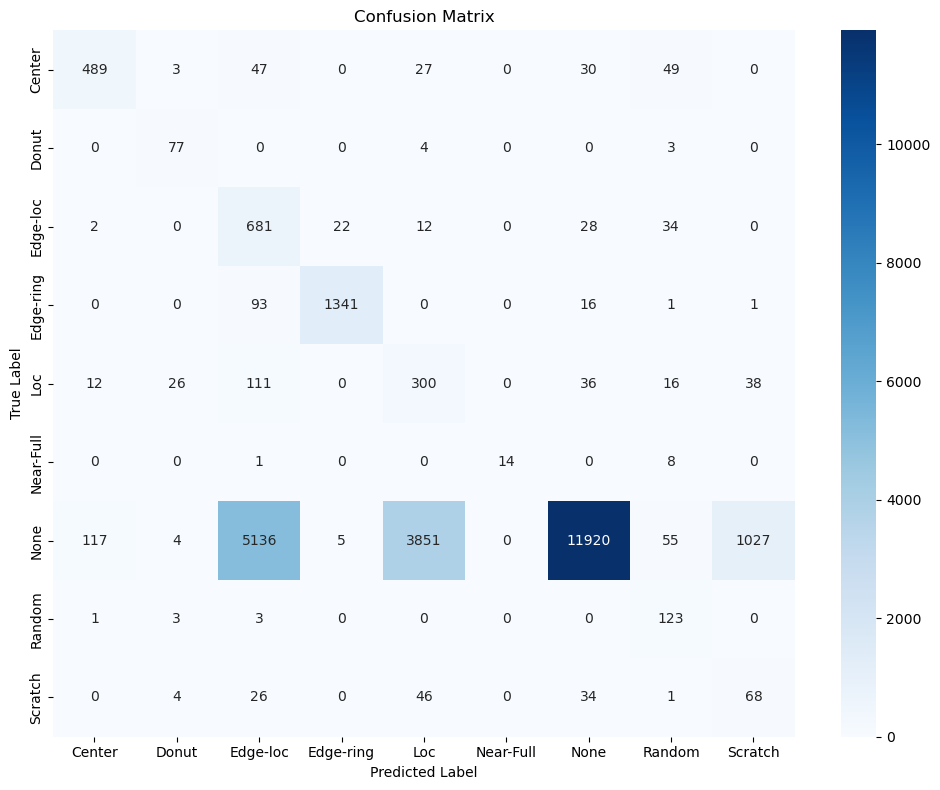

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
test_dir   = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset/test"
test_datagen = ImageDataGenerator(
    rescale=1./255
)
test_set = test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)
# 真實與預測
y_true =test_set.classes
y_pred_prob = model.predict(test_set, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# 類別名稱（依照 index 排序）
class_names = list(test_set.class_indices.keys())

# 混淆矩陣
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [9]:
report = classification_report(y_true, y_pred, target_names=train_set.class_indices.keys())
print(report)


              precision    recall  f1-score   support

      Center       0.79      0.76      0.77       645
       Donut       0.66      0.92      0.77        84
    Edge-loc       0.11      0.87      0.20       779
   Edge-ring       0.98      0.92      0.95      1452
         Loc       0.07      0.56      0.13       539
   Near-Full       1.00      0.61      0.76        23
        None       0.99      0.54      0.70     22115
      Random       0.42      0.95      0.59       130
     Scratch       0.06      0.38      0.10       179

    accuracy                           0.58     25946
   macro avg       0.56      0.72      0.55     25946
weighted avg       0.93      0.58      0.68     25946

